In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score,roc_auc_score

In [8]:
df= pd.read_csv(r"C:\Users\Lenovo\Downloads\GitHub projects\Loan_data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9254 entries, 0 to 9253
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             9254 non-null   object 
 1   Age                         9254 non-null   int64  
 2   AnnualIncome                7998 non-null   float64
 3   CreditScore                 9254 non-null   int64  
 4   EmploymentStatus            9254 non-null   object 
 5   EducationLevel              7955 non-null   object 
 6   Experience                  7973 non-null   float64
 7   LoanAmount                  9254 non-null   int64  
 8   LoanDuration                9254 non-null   int64  
 9   MaritalStatus               7934 non-null   object 
 10  NumberOfDependents          7986 non-null   float64
 11  HomeOwnershipStatus         8009 non-null   object 
 12  MonthlyDebtPayments         8008 non-null   float64
 13  CreditCardUtilizationRate   7901 

In [9]:
df.shape

(9254, 36)

In [10]:
df.isnull().sum()

ApplicationDate                  0
Age                              0
AnnualIncome                  1256
CreditScore                      0
EmploymentStatus                 0
EducationLevel                1299
Experience                    1281
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1320
NumberOfDependents            1268
HomeOwnershipStatus           1245
MonthlyDebtPayments           1246
CreditCardUtilizationRate     1353
NumberOfOpenCreditLines       1278
NumberOfCreditInquiries       1273
DebtToIncomeRatio             1262
BankruptcyHistory             1300
LoanPurpose                   1258
PreviousLoanDefaults          1335
PaymentHistory                1296
LengthOfCreditHistory         1288
SavingsAccountBalance         1284
CheckingAccountBalance        1308
TotalAssets                   1327
TotalLiabilities              1272
MonthlyIncome                 1334
UtilityBillsPaymentHistory    1287
JobTenure           

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9249    False
9250    False
9251    False
9252    False
9253    False
Length: 9254, dtype: bool

In [12]:
for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col]=df[col].fillna(df[col].median())
df.isnull().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [13]:
df['Creditworthy'] = (df['RiskScore'] >= 70).astype(int)

In [14]:
df.isnull().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

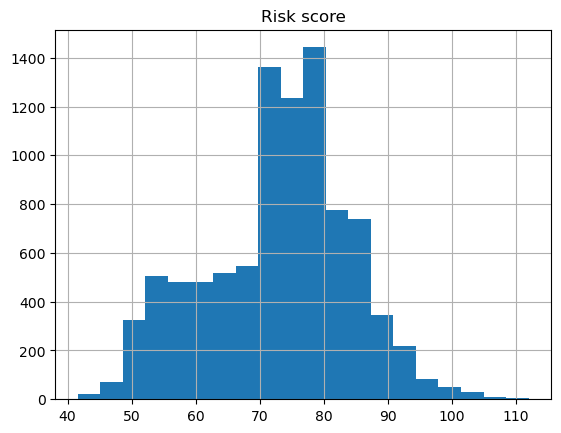

In [15]:
df['RiskScore'].hist(bins=20)
plt.title('Risk score')
plt.show()

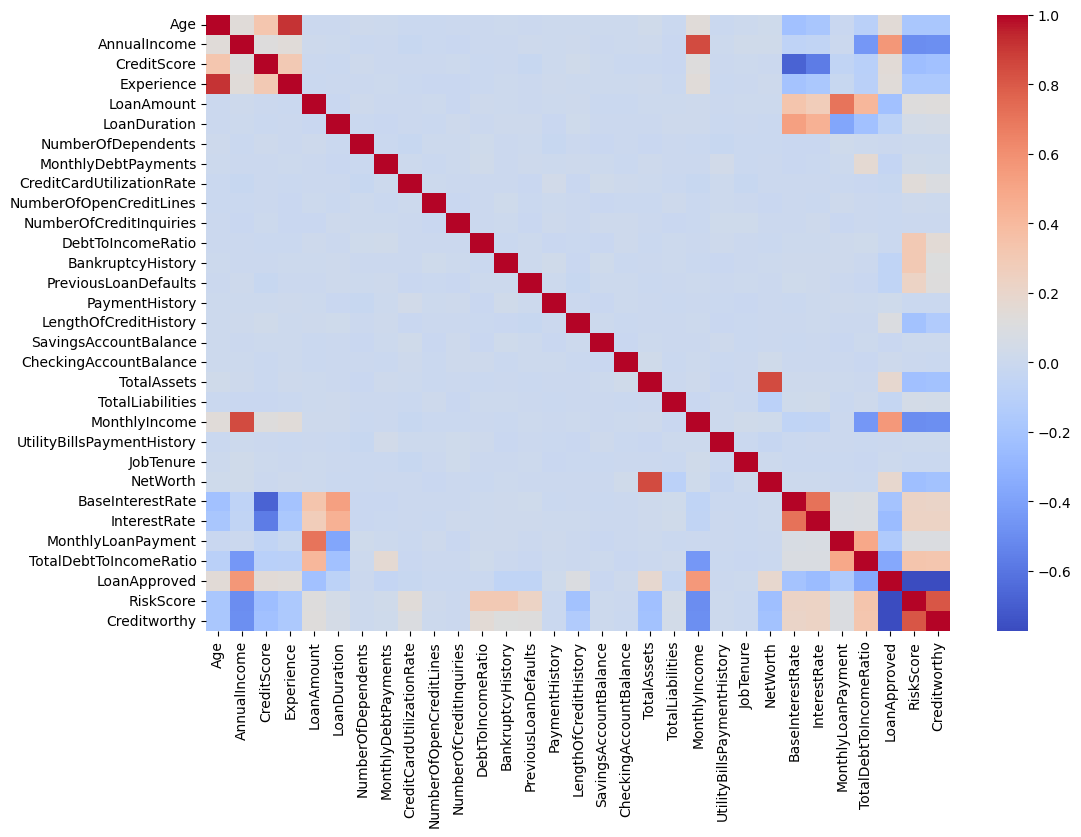

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

In [17]:
df.groupby(pd.qcut(df['AnnualIncome'],4),observed=False)['RiskScore'].mean()

AnnualIncome
(14999.999, 33570.5]    78.822645
(33570.5, 48122.5]      74.906630
(48122.5, 68689.75]     73.100059
(68689.75, 462863.0]    64.106655
Name: RiskScore, dtype: float64

In [18]:
df.groupby('PaymentHistory')['RiskScore'].mean()

PaymentHistory
6.0     79.000000
9.0     81.500000
10.0    70.000000
11.0    68.820000
12.0    72.063636
13.0    73.930233
14.0    73.160494
15.0    73.671074
16.0    72.782390
17.0    72.941634
18.0    72.578248
19.0    73.103518
20.0    73.309434
21.0    72.487986
22.0    73.270458
23.0    73.034621
24.0    72.583684
25.0    73.214122
26.0    72.308738
27.0    73.618359
28.0    72.634259
29.0    72.510738
30.0    72.925000
31.0    73.409649
32.0    72.197605
33.0    72.575410
34.0    71.965432
35.0    73.088000
36.0    72.350000
37.0    73.044444
38.0    68.820000
39.0    75.545455
40.0    75.200000
42.0    75.000000
43.0    73.000000
44.0    81.500000
Name: RiskScore, dtype: float64

In [19]:
df.groupby(pd.qcut(df['DebtToIncomeRatio'],4),observed=False)['RiskScore'].mean()

DebtToIncomeRatio
(0.0012200000000000002, 0.176]    68.904581
(0.176, 0.263]                    71.661617
(0.263, 0.361]                    73.235791
(0.361, 0.913]                    78.052204
Name: RiskScore, dtype: float64

In [20]:
X = df[
[
'Age',
'AnnualIncome',
'CreditScore',
'LoanAmount',
'MonthlyDebtPayments',
'DebtToIncomeRatio',
'PaymentHistory',
'PreviousLoanDefaults',
'LengthOfCreditHistory',
'SavingsAccountBalance',
'TotalAssets',
'TotalLiabilities',
'NetWorth']]
y = df['Creditworthy']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [23]:
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC AUC   :", roc_auc_score(y_test, y_prob))

Precision : 0.8897058823529411
Recall    : 0.8615506329113924
F1 Score  : 0.8754019292604501
ROC AUC   : 0.8976438336963317


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.77      0.74       587
           1       0.89      0.86      0.88      1264

    accuracy                           0.83      1851
   macro avg       0.81      0.82      0.81      1851
weighted avg       0.84      0.83      0.83      1851



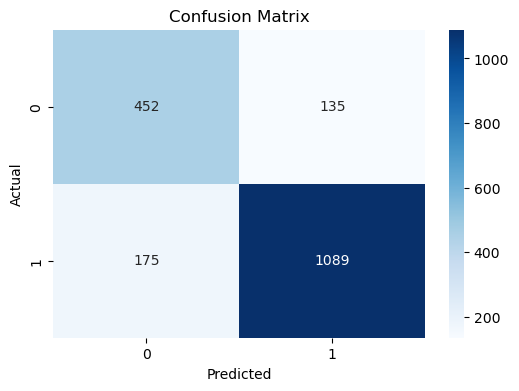

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

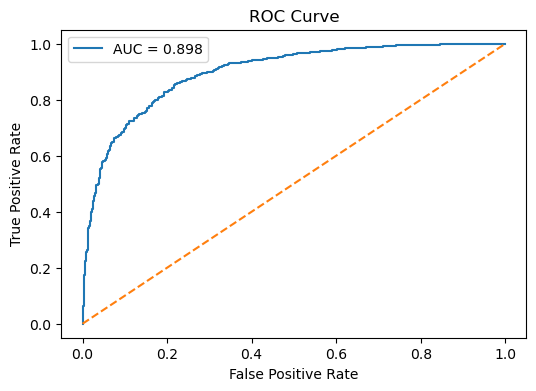

In [26]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Random Forest

In [27]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [27]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [28]:
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC AUC   :", roc_auc_score(y_test, y_prob))

Precision : 0.858192505510654
Recall    : 0.9240506329113924
F1 Score  : 0.8899047619047619
ROC AUC   : 0.9142247374549846


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73       587
           1       0.86      0.92      0.89      1264

    accuracy                           0.84      1851
   macro avg       0.83      0.80      0.81      1851
weighted avg       0.84      0.84      0.84      1851



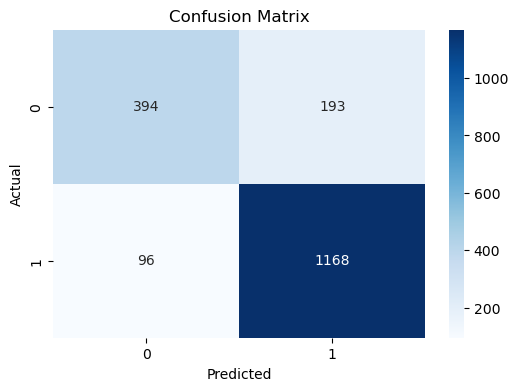

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

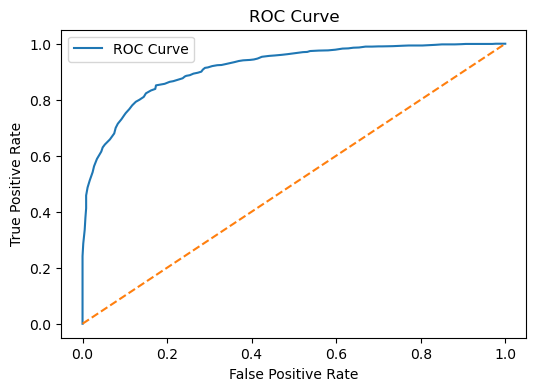

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

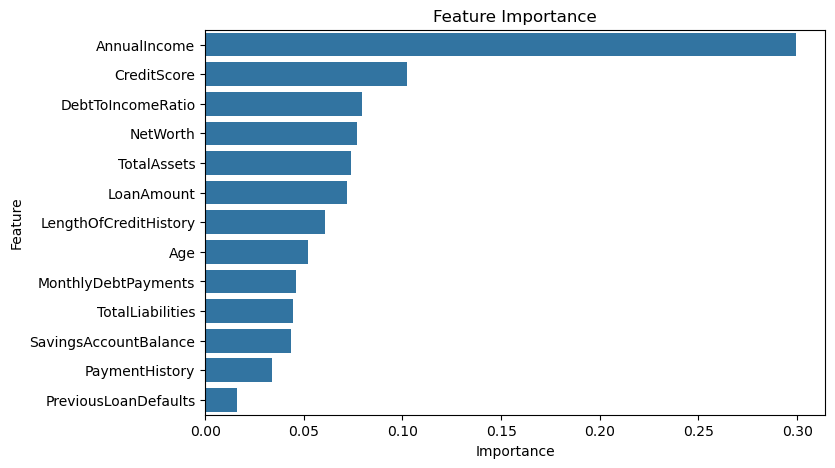

In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title('Feature Importance')
plt.show()